<a href="https://colab.research.google.com/github/IronZiiz/Domain-specific_finetunning/blob/main/Phase_1_Training_Hyperparameter_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1 — Training Hyperparameter Exploration
This notebook implements **Methods 2.4.1** of the manuscript:


**Objective:** Systematically explore the effect of training hyperparameters on Cellpose CPSAM fine-tuning for trigeminal ganglion neuron segmentation.

**Fixed setup:**
- Hold-out split: 21 train / 5 test (80/20)
- No data augmentation in this phase
- `batch_size = 1`
- Single GPU (consistent across all runs)

**Sequential search strategy:**

| Sub-phase | Variable | Search Space | Fixed |
|-----------|----------|--------------|-------|
| **1A** | `n_epochs` | [1, 10, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 260, 300, 350, 400, 500] | `lr=1e-5`, `wd=0.1` |
| **1B** | `learning_rate` | [1e-6, 5e-6, 1e-5, 2e-5, 5e-5, 1e-4, 1e-3] | best `n_epochs` from 1A, `wd=0.1` |
| **1C** | `weight_decay` | [1e-4, 1e-3, 1e-2, 5e-2, 1e-1, 5e-1] | best `n_epochs` from 1A, best `lr` from 1B |
| **1D** | `lr × wd` (2D grid) | refined around best | best `n_epochs` from 1A |

**Inference parameters (fixed for all sub-phases):**
- `diameter = None` (auto-detection)
- `channel_axis = -1`
- All other parameters: Cellpose defaults

**Output artifacts per model:**
- Model checkpoint (`.pth`)
- Aggregated metrics: AP@0.5, AP@0.75, AP@0.9, Precision, Recall, F1, TP, FP, FN
- Per-image metrics: same metrics for each test image
- Training time and final train loss

## 0. Environment Setup

**Important:** Colab sometimes comes with numpy versions incompatible with newer scientific libraries (causes `_blas_supports_fpe` AttributeError). The cell below pins compatible versions and restarts the runtime if needed.

In [ ]:
!pip install --quiet cellpose
!pip install --quiet albumentations

import os
import sys

import importlib
import numpy as np

if np.__version__ < "2.0":
    print(f"WARNING: numpy version {np.__version__} is too old. Please restart runtime (Runtime > Restart session) and run this cell again.")
else:
    print(f"numpy version: {np.__version__} OK")

numpy version: 2.5.1 OK


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import json
import time
import gc
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from cellpose import models, train, io
from cellpose.metrics import average_precision

import cellpose
print(f"Cellpose version: {cellpose.version}")
print(f"Torch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Cellpose version: 4.2.1.1
Torch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


## 1. Configuration


### ⚠️ IMPORTANT: External Data Requirement

To use this notebook, you must provide your own histology dataset. If you do not have access, please request it from the research team.

**Required Directory Structure:**
Place your data in a folder named `./dataset/` with `train` and `test` subdirectories containing your `.tif` images and corresponding `_masks.tif` files.

In [ ]:
import os
from pathlib import Path
import numpy as np
import torch

# --- PORTABLE PATH CONFIGURATION ---
# Change these to point to your local data location
DATASET_ROOT = Path("./dataset")
TRAIN_DATA_PATH = DATASET_ROOT / "train"
TEST_DATA_PATH = DATASET_ROOT / "test"

# Directory where results and models will be saved
OUTPUT_DIR = Path("./phase1_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- SUBPHASE DIRECTORIES ---
SUBPHASE_DIRS = {
    "1A_epochs": OUTPUT_DIR / "1A_epochs",
    "1B_learning_rate": OUTPUT_DIR / "1B_learning_rate",
    "1C_weight_decay": OUTPUT_DIR / "1C_weight_decay",
    "1D_lr_wd_grid": OUTPUT_DIR / "1D_lr_wd_grid",
}

for d in SUBPHASE_DIRS.values():
    (d / "models").mkdir(parents=True, exist_ok=True)
    (d / "metrics").mkdir(parents=True, exist_ok=True)
    (d / "per_image_metrics").mkdir(parents=True, exist_ok=True)

# --- HYPERPARAMETER SEARCH SPACES ---
EPOCHS_TO_TEST = [1, 10, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 260, 300, 350, 400, 500]
LEARNING_RATES_TO_TEST = [1e-6, 5e-6, 1e-5, 2e-5, 5e-5, 1e-4, 1e-3]
WEIGHT_DECAYS_TO_TEST = [1e-4, 1e-3, 1e-2, 5e-2, 1e-1, 5e-1]

DEFAULT_LR = 1e-5
DEFAULT_WD = 0.1
BATCH_SIZE = 1
RANDOM_SEED = 42
IOU_THRESHOLDS = [0.5, 0.75, 0.9]

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print(f"Data Root: {DATASET_ROOT.absolute()}")
print(f"Output directory: {OUTPUT_DIR.absolute()}")

In [ ]:
import os
from pathlib import Path
import numpy as np
import torch

# --- PORTABLE CONFIGURATION ---
# All paths are now relative to allow any user to run the code
DATASET_ROOT = Path("./dataset")
TRAIN_DATA_PATH = DATASET_ROOT / "train"
TEST_DATA_PATH = DATASET_ROOT / "test"

# Results will be saved locally in the current working directory
OUTPUT_DIR = Path("./phase1_exploration_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- SUBPHASE SETUP ---
SUBPHASE_DIRS = {
    "1A_epochs": OUTPUT_DIR / "1A_epochs",
    "1B_learning_rate": OUTPUT_DIR / "1B_learning_rate",
    "1C_weight_decay": OUTPUT_DIR / "1C_weight_decay",
    "1D_lr_wd_grid": OUTPUT_DIR / "1D_lr_wd_grid",
}

for d in SUBPHASE_DIRS.values():
    (d / "models").mkdir(parents=True, exist_ok=True)
    (d / "metrics").mkdir(parents=True, exist_ok=True)
    (d / "per_image_metrics").mkdir(parents=True, exist_ok=True)

# --- GLOBAL PARAMETERS ---
EPOCHS_TO_TEST = [1, 10, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 260, 300, 350, 400, 500]
LEARNING_RATES_TO_TEST = [1e-6, 5e-6, 1e-5, 2e-5, 5e-5, 1e-4, 1e-3]
WEIGHT_DECAYS_TO_TEST = [1e-4, 1e-3, 1e-2, 5e-2, 1e-1, 5e-1]

DEFAULT_LR = 1e-5
DEFAULT_WD = 0.1
BATCH_SIZE = 1
RANDOM_SEED = 42
IOU_THRESHOLDS = [0.5, 0.75, 0.9]

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print(f"Dataset Path: {DATASET_ROOT.absolute()}")
print(f"Outputs Path: {OUTPUT_DIR.absolute()}")

Output directory: /content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration

--- Search spaces ---
1A (epochs): 18 values
1B (learning rate): 7 values
1C (weight decay): 6 values
1D (lr x wd grid): refined after 1B and 1C


## 2. Data Loading

**Note:** Adapt the loading logic if your dataset structure (filenames, mask format) differs from what is assumed here.

In [ ]:
def load_image_and_mask(img_path, mask_path):
    img = io.imread(str(img_path))

    if img.ndim == 3 and img.shape[-1] == 4:
        img = img[:, :, :3]

    mask = io.imread(str(mask_path))

    return img, mask


def load_dataset(folder_path):
    folder = Path(folder_path)

    img_files = sorted([
        f for f in folder.glob("*")
        if f.suffix.lower() in [".tif", ".tiff", ".png", ".jpg"]
        and "_mask" not in f.stem
        and "_masks" not in f.stem
        and "_seg" not in f.stem
    ])

    images, masks, names = [], [], []

    for img_file in img_files:
        possible_mask_paths = [
            folder / f"{img_file.stem}_masks.tif",
            folder / f"{img_file.stem}_masks.png",
            folder / f"{img_file.stem}_mask.tif",
            folder / f"{img_file.stem}_seg.npy",
        ]

        mask_path = None
        for p in possible_mask_paths:
            if p.exists():
                mask_path = p
                break

        if mask_path is None:
            print(f"WARNING: no mask for {img_file.name}")
            continue

        if mask_path.suffix == ".npy":
            seg_data = np.load(str(mask_path), allow_pickle=True).item()
            mask = seg_data["masks"]
            img = io.imread(str(img_file))
            if img.ndim == 3 and img.shape[-1] == 4:
                img = img[:, :, :3]
        else:
            img, mask = load_image_and_mask(img_file, mask_path)

        images.append(img)
        masks.append(mask)
        names.append(img_file.stem)

    return images, masks, names


train_images, train_masks, train_names = load_dataset(TRAIN_DATA_PATH)
test_images, test_masks, test_names = load_dataset(TEST_DATA_PATH)

print(f"Train: {len(train_images)} images")
print(f"Test: {len(test_images)} images")
print(f"\nTrain images: {train_names}")
print(f"Test images: {test_names}")
print(f"\nFirst train image shape: {train_images[0].shape}")
print(f"First train mask shape: {train_masks[0].shape}, unique masks: {len(np.unique(train_masks[0]))-1}")

Train: 21 images
Test: 5 images

Train images: ['11', '12', '13', '14', '16', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '3', '4', '5', '6', '8', '9']
Test images: ['1', '10', '15', '17', '7']

First train image shape: (1920, 2560, 3)
First train mask shape: (1920, 2560), unique masks: 33


In [ ]:
test_manifest = {
    "n_train": len(train_images),
    "n_test": len(test_images),
    "train_image_names": train_names,
    "test_image_names": test_names,
    "fixed_split": True,
    "random_seed": RANDOM_SEED,
    "ground_truth_neurons_test": int(sum(len(np.unique(m)) - 1 for m in test_masks)),
}

with open(OUTPUT_DIR / "dataset_manifest.json", "w") as f:
    json.dump(test_manifest, f, indent=4)

print(json.dumps(test_manifest, indent=2))

{
  "n_train": 21,
  "n_test": 5,
  "train_image_names": [
    "11",
    "12",
    "13",
    "14",
    "16",
    "18",
    "19",
    "2",
    "20",
    "21",
    "22",
    "23",
    "24",
    "25",
    "26",
    "3",
    "4",
    "5",
    "6",
    "8",
    "9"
  ],
  "test_image_names": [
    "1",
    "10",
    "15",
    "17",
    "7"
  ],
  "fixed_split": true,
  "random_seed": 42,
  "ground_truth_neurons_test": 310
}


## 3. Evaluation Functions

In [ ]:
def compute_metrics_at_threshold(test_labels, predicted_masks, threshold):
    ap, tp, fp, fn = average_precision(
        test_labels,
        predicted_masks,
        threshold=[threshold]
    )

    ap_per_image = ap.flatten().tolist()
    tp_per_image = tp.flatten().astype(int).tolist()
    fp_per_image = fp.flatten().astype(int).tolist()
    fn_per_image = fn.flatten().astype(int).tolist()

    total_tp = int(np.sum(tp))
    total_fp = int(np.sum(fp))
    total_fn = int(np.sum(fn))

    mean_ap = float(np.mean(ap))

    precision = total_tp / (total_tp + total_fp + 1e-8)
    recall = total_tp / (total_tp + total_fn + 1e-8)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

    precision_per_image = [
        t / (t + f + 1e-8) for t, f in zip(tp_per_image, fp_per_image)
    ]
    recall_per_image = [
        t / (t + f + 1e-8) for t, f in zip(tp_per_image, fn_per_image)
    ]
    f1_per_image = [
        2 * (p * r) / (p + r + 1e-8) for p, r in zip(precision_per_image, recall_per_image)
    ]

    return {
        "aggregate": {
            "AP": mean_ap,
            "TP": total_tp,
            "FP": total_fp,
            "FN": total_fn,
            "Precision": float(precision),
            "Recall": float(recall),
            "F1": float(f1),
        },
        "per_image": {
            "AP": ap_per_image,
            "TP": tp_per_image,
            "FP": fp_per_image,
            "FN": fn_per_image,
            "Precision": precision_per_image,
            "Recall": recall_per_image,
            "F1": f1_per_image,
        }
    }


def evaluate_model(model, test_data, test_labels, test_names_list):
    predicted_masks = []
    inference_times = []

    for img in test_data:
        t0 = time.time()
        masks_pred, _, _ = model.eval(
            img,
            diameter=None,
            channel_axis=-1
        )
        inference_times.append(time.time() - t0)
        predicted_masks.append(masks_pred)

    results = {
        "thresholds": {},
        "per_image_thresholds": {},
        "inference_time_s": inference_times,
        "test_image_names": test_names_list,
    }

    for thr in IOU_THRESHOLDS:
        metrics = compute_metrics_at_threshold(test_labels, predicted_masks, thr)
        results["thresholds"][f"AP@{thr}"] = metrics["aggregate"]
        results["per_image_thresholds"][f"AP@{thr}"] = metrics["per_image"]

    return results


def free_gpu_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [ ]:
def train_and_evaluate(n_epochs, learning_rate, weight_decay,
                       subphase_dir, run_label,
                       train_data, train_labels, test_data, test_labels, test_names_list):

    model_name = f"{run_label}_ep{n_epochs}_lr{learning_rate}_wd{weight_decay}_bs{BATCH_SIZE}"

    print(f"\n{'='*70}")
    print(f"TRAINING: {model_name}")
    print(f"{'='*70}")

    free_gpu_memory()

    modelo_base = models.CellposeModel(gpu=True)

    start = time.time()

    model_path, train_losses, _ = train.train_seg(
        modelo_base.net,
        train_data=train_data,
        train_labels=train_labels,
        test_data=None,
        test_labels=None,
        batch_size=BATCH_SIZE,
        n_epochs=n_epochs,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        nimg_per_epoch=len(train_data),
        model_name=model_name,
        save_every=max(n_epochs, 1)
    )

    train_time = time.time() - start

    models_dir = subphase_dir / "models"
    final_model_path = models_dir / f"{model_name}.pth"
    modelo_base.net.save_model(str(final_model_path))

    print(f"Model saved: {final_model_path}")
    print(f"Training time: {train_time:.2f}s ({train_time/60:.2f}min)")

    print("Evaluating on test set...")
    eval_start = time.time()
    eval_results = evaluate_model(modelo_base, test_data, test_labels, test_names_list)
    eval_time = time.time() - eval_start

    full_results = {
        "model_name": model_name,
        "model_path": str(final_model_path),
        "hyperparameters": {
            "n_epochs": n_epochs,
            "learning_rate": learning_rate,
            "weight_decay": weight_decay,
            "batch_size": BATCH_SIZE,
            "diameter": None,
            "channel_axis": -1,
        },
        "training_time_seconds": train_time,
        "evaluation_time_seconds": eval_time,
        "train_loss_final": float(train_losses[-1]) if len(train_losses) > 0 else None,
        "train_losses_curve": [float(x) for x in train_losses],
        "test_image_names": test_names_list,
        "aggregate_metrics": eval_results["thresholds"],
        "per_image_metrics": eval_results["per_image_thresholds"],
        "inference_time_per_image_s": eval_results["inference_time_s"],
    }

    metrics_file = subphase_dir / "metrics" / f"{model_name}_metrics.json"
    with open(metrics_file, "w") as f:
        json.dump(full_results, f, indent=4)

    per_image_records = []
    for i, img_name in enumerate(test_names_list):
        record = {
            "image_name": img_name,
            "model": model_name,
            "n_epochs": n_epochs,
            "learning_rate": learning_rate,
            "weight_decay": weight_decay,
        }
        for thr in IOU_THRESHOLDS:
            key = f"AP@{thr}"
            per_image = eval_results["per_image_thresholds"][key]
            record[f"{key}_AP"] = per_image["AP"][i]
            record[f"{key}_TP"] = per_image["TP"][i]
            record[f"{key}_FP"] = per_image["FP"][i]
            record[f"{key}_FN"] = per_image["FN"][i]
            record[f"{key}_Precision"] = per_image["Precision"][i]
            record[f"{key}_Recall"] = per_image["Recall"][i]
            record[f"{key}_F1"] = per_image["F1"][i]
        per_image_records.append(record)

    df_per_image = pd.DataFrame(per_image_records)
    per_image_csv = subphase_dir / "per_image_metrics" / f"{model_name}_per_image.csv"
    df_per_image.to_csv(per_image_csv, index=False)

    print(f"\nResults at AP@0.5:")
    agg_05 = eval_results["thresholds"]["AP@0.5"]
    print(f"  AP@0.5: {agg_05['AP']:.4f}")
    print(f"  Precision: {agg_05['Precision']:.4f}")
    print(f"  Recall: {agg_05['Recall']:.4f}")
    print(f"  F1: {agg_05['F1']:.4f}")
    print(f"  TP: {agg_05['TP']}, FP: {agg_05['FP']}, FN: {agg_05['FN']}")
    print(f"AP@0.75: {eval_results['thresholds']['AP@0.75']['AP']:.4f}")
    print(f"AP@0.9: {eval_results['thresholds']['AP@0.9']['AP']:.4f}")

    del modelo_base
    free_gpu_memory()

    return full_results


def consolidate_subphase_results(subphase_results, subphase_dir, subphase_name):
    summary_records = []

    for r in subphase_results:
        record = {
            "n_epochs": r["hyperparameters"]["n_epochs"],
            "learning_rate": r["hyperparameters"]["learning_rate"],
            "weight_decay": r["hyperparameters"]["weight_decay"],
            "model_name": r["model_name"],
            "training_time_s": r["training_time_seconds"],
            "train_loss_final": r["train_loss_final"],
        }

        for thr in IOU_THRESHOLDS:
            key = f"AP@{thr}"
            agg = r["aggregate_metrics"][key]
            record[f"{key}_AP"] = agg["AP"]
            record[f"{key}_TP"] = agg["TP"]
            record[f"{key}_FP"] = agg["FP"]
            record[f"{key}_FN"] = agg["FN"]
            record[f"{key}_Precision"] = agg["Precision"]
            record[f"{key}_Recall"] = agg["Recall"]
            record[f"{key}_F1"] = agg["F1"]

        summary_records.append(record)

    df_summary = pd.DataFrame(summary_records)
    summary_csv = subphase_dir / f"{subphase_name}_summary.csv"
    df_summary.to_csv(summary_csv, index=False)
    print(f"\nSummary saved: {summary_csv}")

    return df_summary

## Sub-Phase 1A — Number of Epochs Exploration

In [ ]:
subphase_dir = SUBPHASE_DIRS["1A_epochs"]
results_1A = []

for epoch_count in EPOCHS_TO_TEST:
    try:
        result = train_and_evaluate(
            n_epochs=epoch_count,
            learning_rate=DEFAULT_LR,
            weight_decay=DEFAULT_WD,
            subphase_dir=subphase_dir,
            run_label="1A",
            train_data=train_images,
            train_labels=train_masks,
            test_data=test_images,
            test_labels=test_masks,
            test_names_list=test_names,
        )
        results_1A.append(result)

        with open(subphase_dir / "results_partial.json", "w") as f:
            json.dump(results_1A, f, indent=4)

        print(f"\n[1A Progress: {len(results_1A)}/{len(EPOCHS_TO_TEST)}]")

    except Exception as e:
        print(f"ERROR at n_epochs={epoch_count}: {e}")
        import traceback
        traceback.print_exc()
        free_gpu_memory()
        continue

with open(subphase_dir / "results_final.json", "w") as f:
    json.dump(results_1A, f, indent=4)

df_1A = consolidate_subphase_results(results_1A, subphase_dir, "1A_epochs")
df_1A_sorted = df_1A.sort_values("n_epochs").reset_index(drop=True)
df_1A_sorted


TRAINING: 1A_ep1_lr1e-05_wd0.1_bs1


100%|██████████| 1.15G/1.15G [00:04<00:00, 295MB/s]
100%|██████████| 21/21 [00:00<00:00, 157.65it/s]


Model saved: /content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration/1A_epochs/models/1A_ep1_lr1e-05_wd0.1_bs1.pth
Training time: 15.34s (0.26min)
Evaluating on test set...


/usr/local/lib/python3.12/dist-packages/cellpose/dynamics.py:524: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),



Results at AP@0.5:
  AP@0.5: 0.0022
  Precision: 0.0022
  Recall: 0.0194
  F1: 0.0040
  TP: 6, FP: 2720, FN: 304
AP@0.75: 0.0011
AP@0.9: 0.0000

[1A Progress: 1/18]

TRAINING: 1A_ep10_lr1e-05_wd0.1_bs1


...

100%|██████████| 21/21 [00:00<00:00, 156.74it/s]


Model saved: /content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration/1A_epochs/models/1A_ep400_lr1e-05_wd0.1_bs1.pth
Training time: 772.61s (12.88min)
Evaluating on test set...

Results at AP@0.5:
  AP@0.5: 0.7678
  Precision: 0.8506
  Recall: 0.9000
  F1: 0.8746
  TP: 279, FP: 49, FN: 31
AP@0.75: 0.6667
AP@0.9: 0.1213

[1A Progress: 17/18]

TRAINING: 1A_ep500_lr1e-05_wd0.1_bs1


100%|██████████| 21/21 [00:00<00:00, 156.66it/s]


Model saved: /content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration/1A_epochs/models/1A_ep500_lr1e-05_wd0.1_bs1.pth
Training time: 956.58s (15.94min)
Evaluating on test set...

Results at AP@0.5:
  AP@0.5: 0.7556
  Precision: 0.8682
  Recall: 0.8710
  F1: 0.8696
  TP: 270, FP: 41, FN: 40
AP@0.75: 0.6579
AP@0.9: 0.1111

[1A Progress: 18/18]

Summary saved: /content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration/1A_epochs/1A_epochs_summary.csv


,n_epochs,learning_rate,weight_decay,model_name,training_time_s,train_loss_final,AP@0.5_AP,AP@0.5_TP,AP@0.5_FP,AP@0.5_FN,...,AP@0.75_Precision,AP@0.75_Recall,AP@0.75_F1,AP@0.9_AP,AP@0.9_TP,AP@0.9_FP,AP@0.9_FN,AP@0.9_Precision,AP@0.9_Recall,AP@0.9_F1
0,1,0.00001,0.1,1A_ep1_lr1e-05_wd0.1_bs1,15.338246,1.131013,0.002218,6,2720,304,...,0.001101,0.009677,0.001976,0.000000,0,2726,310,0.000000,0.000000,0.000000
1,10,0.00001,0.1,1A_ep10_lr1e-05_wd0.1_bs1,30.890326,0.461253,0.696540,289,97,21,...,0.637306,0.793548,0.706897,0.051757,42,344,268,0.108808,0.135484,0.120690
2,20,0.00001,0.1,1A_ep20_lr1e-05_wd0.1_bs1,50.484099,0.428014,0.732980,271,57,39,...,0.725610,0.767742,0.746081,0.047690,36,292,274,0.109756,0.116129,0.112853
3,40,0.00001,0.1,1A_ep40_lr1e-05_wd0.1_bs1,88.521643,0.626494,0.689706,289,96,21,...,0.703896,0.874194,0.779856,0.108718,77,308,233,0.200000,0.248387,0.221583
4,60,0.00001,0.1,1A_ep60_lr1e-05_wd0.1_bs1,128.664167,0.458900,0.731030,249,32,61,...,0.818505,0.741935,0.778342,0.093148,59,222,251,0.209964,0.190323,0.199662
5,80,0.00001,0.1,1A_ep80_lr1e-05_wd0.1_bs1,161.314670,0.408127,0.726876,280,63,30,...,0.740525,0.819355,0.777948,0.103285,70,273,240,0.204082,0.225806,0.214395
6,100,0.00001,0.1,1A_ep100_lr1e-05_wd0.1_bs1,197.616669,0.368056,0.761176,264,35,46,...,0.806020,0.777419,0.791461,0.104655,66,233,244,0.220736,0.212903,0.216749
7,120,0.00001,0.1,1A_ep120_lr1e-05_wd0.1_bs1,238.112570,0.462215,0.744874,279,58,31,...,0.759644,0.825806,0.791345,0.091932,60,277,250,0.178042,0.193548,0.185471
8,140,0.00001,0.1,1A_ep140_lr1e-05_wd0.1_bs1,276.876324,0.431347,0.742785,272,49,38,...,0.785047,0.812903,0.798732,0.101849,64,257,246,0.199377,0.206452,0.202853
9,160,0.00001,0.1,1A_ep160_lr1e-05_wd0.1_bs1,317.046638,0.301932,0.764695,270,40,40,...,0.800000,0.800000,0.800000,0.103598,65,245,245,0.209677,0.209677,0.209677


### 1A — Quick Visualization

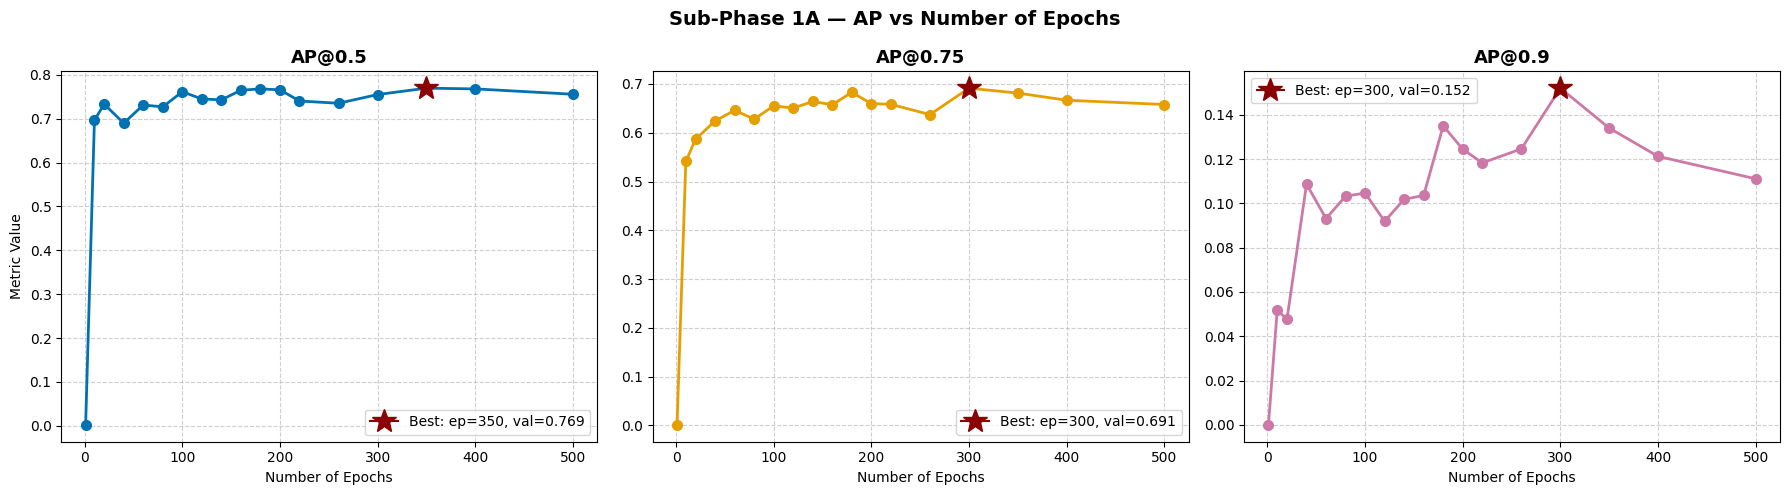

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

ap_metrics = ['AP@0.5_AP', 'AP@0.75_AP', 'AP@0.9_AP']
titles = ['AP@0.5', 'AP@0.75', 'AP@0.9']
colors = ['#0072B2', '#E69F00', '#CC79A7']

for ax, metric, title, color in zip(axes, ap_metrics, titles, colors):
    ax.plot(df_1A_sorted["n_epochs"], df_1A_sorted[metric],
            marker='o', linewidth=2, markersize=7, color=color)

    best_idx = df_1A_sorted[metric].idxmax()
    best_ep = df_1A_sorted.loc[best_idx, "n_epochs"]
    best_val = df_1A_sorted.loc[best_idx, metric]
    ax.plot(best_ep, best_val, marker='*', markersize=18, color='darkred', zorder=5,
            label=f"Best: ep={best_ep}, val={best_val:.3f}")

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel("Number of Epochs")
    if ax == axes[0]:
        ax.set_ylabel("Metric Value")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

fig.suptitle("Sub-Phase 1A — AP vs Number of Epochs", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(subphase_dir / "1A_ap_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# Epoch selection: one-standard-error rule (Breiman et al., 1984; Hastie et al., 2009)
# ---------------------------------------------------------------------------
# Sub-phase 1A is NOT re-run here; it is already complete. We only DECIDE the
# number of epochs to carry forward into 1B/1C/1D.
#
# The peak AP@50 occurs at 350 epochs (AP@50 = 0.769, SE ~= 0.025), giving a
# one-standard-error threshold of 0.769 - 0.025 = 0.744. The smallest number of
# epochs whose AP@50 remains within this threshold is 100 epochs (AP@50 = 0.761).
# By the one-standard-error rule, 100 epochs is the most parsimonious choice that
# is statistically indistinguishable from the peak, at ~71% lower training cost.
#
# The value is fixed explicitly (rather than recomputed) because the epoch sweep
# has already been analysed and verified.
BEST_EPOCHS = 100

In [ ]:

# For reference/logging, also report the raw argmax of the epoch sweep.
_argmax_epoch = int(df_1A_sorted.loc[df_1A_sorted["AP@0.5_AP"].idxmax(), "n_epochs"])
_argmax_ap    = float(df_1A_sorted["AP@0.5_AP"].max())
print(f"Epoch sweep argmax (AP@0.5): {_argmax_epoch} epochs (AP@0.5 = {_argmax_ap:.4f})")
print(f"Selected n_epochs (one-standard-error rule): {BEST_EPOCHS}")
print(f"\nThis value will be used in Sub-Phases 1B, 1C and 1D.")


NameError: name 'df_1A_sorted' is not defined

## Sub-Phase 1B — Learning Rate Exploration

Fixed: `n_epochs = BEST_EPOCHS` (from 1A), `weight_decay = 0.1`
Variable: `learning_rate` across 7 values

**Hypothesis based on prior experiments:** `lr > 1e-5` may cause catastrophic collapse for CPSAM fine-tuning. This sub-phase confirms this behavior with finer granularity.

In [ ]:
subphase_dir = SUBPHASE_DIRS["1B_learning_rate"]


In [ ]:
subphase_dir = SUBPHASE_DIRS["1B_learning_rate"]
results_1B = []

for lr in LEARNING_RATES_TO_TEST:
    try:
        result = train_and_evaluate(
            n_epochs=BEST_EPOCHS,
            learning_rate=lr,
            weight_decay=DEFAULT_WD,
            subphase_dir=subphase_dir,
            run_label="1B",
            train_data=train_images,
            train_labels=train_masks,
            test_data=test_images,
            test_labels=test_masks,
            test_names_list=test_names,
        )
        results_1B.append(result)

        with open(subphase_dir / "results_partial_100.json", "w") as f:
            json.dump(results_1B, f, indent=4)

        print(f"\n[1B Progress: {len(results_1B)}/{len(LEARNING_RATES_TO_TEST)}]")

    except Exception as e:
        print(f"ERROR at lr={lr}: {e}")
        import traceback
        traceback.print_exc()
        free_gpu_memory()
        continue

with open(subphase_dir / "results_final_100.json", "w") as f:
    json.dump(results_1B, f, indent=4)

df_1B = consolidate_subphase_results(results_1B, subphase_dir, "1B_learning_rate")
df_1B_sorted = df_1B.sort_values("learning_rate").reset_index(drop=True)
df_1B_sorted


TRAINING: 1B_ep100_lr1e-06_wd0.1_bs1


100%|██████████| 1.15G/1.15G [00:08<00:00, 143MB/s]
100%|██████████| 21/21 [00:00<00:00, 157.78it/s]


Model saved: /content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration/1B_learning_rate/models/1B_ep100_lr1e-06_wd0.1_bs1.pth
Training time: 163.29s (2.72min)
Evaluating on test set...


/usr/local/lib/python3.12/dist-packages/cellpose/dynamics.py:541: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),



Results at AP@0.5:
  AP@0.5: 0.7418
  Precision: 0.8129
  Recall: 0.8968
  F1: 0.8528
  TP: 278, FP: 64, FN: 32
AP@0.75: 0.5639
AP@0.9: 0.0756

[1B Progress: 1/7]

TRAINING: 1B_ep100_lr5e-06_wd0.1_bs1


...

100%|██████████| 21/21 [00:00<00:00, 156.27it/s]


Model saved: /content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration/1B_learning_rate/models/1B_ep100_lr0.0001_wd0.1_bs1.pth
Training time: 157.67s (2.63min)
Evaluating on test set...

Results at AP@0.5:
  AP@0.5: 0.7241
  Precision: 0.8799
  Recall: 0.8032
  F1: 0.8398
  TP: 249, FP: 34, FN: 61
AP@0.75: 0.6181
AP@0.9: 0.0786

[1B Progress: 6/7]

TRAINING: 1B_ep100_lr0.001_wd0.1_bs1


100%|██████████| 21/21 [00:00<00:00, 156.45it/s]


Model saved: /content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration/1B_learning_rate/models/1B_ep100_lr0.001_wd0.1_bs1.pth
Training time: 159.13s (2.65min)
Evaluating on test set...

Results at AP@0.5:
  AP@0.5: 0.0000
  Precision: 0.0000
  Recall: 0.0000
  F1: 0.0000
  TP: 0, FP: 0, FN: 310
AP@0.75: 0.0000
AP@0.9: 0.0000

[1B Progress: 7/7]

Summary saved: /content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration/1B_learning_rate/1B_learning_rate_summary.csv


,n_epochs,learning_rate,weight_decay,model_name,training_time_s,train_loss_final,AP@0.5_AP,AP@0.5_TP,AP@0.5_FP,AP@0.5_FN,...,AP@0.75_Precision,AP@0.75_Recall,AP@0.75_F1,AP@0.9_AP,AP@0.9_TP,AP@0.9_FP,AP@0.9_FN,AP@0.9_Precision,AP@0.9_Recall,AP@0.9_F1
0,100,0.000001,0.1,1B_ep100_lr1e-06_wd0.1_bs1,163.286948,0.401040,0.741818,278,64,32,...,0.684211,0.754839,0.717791,0.075600,51,291,259,0.149123,0.164516,0.156442
1,100,0.000005,0.1,1B_ep100_lr5e-06_wd0.1_bs1,159.524729,0.336222,0.733641,264,45,46,...,0.779935,0.777419,0.778675,0.095955,63,246,247,0.203883,0.203226,0.203554
2,100,0.000010,0.1,1B_ep100_lr1e-05_wd0.1_bs1,162.000265,0.363216,0.745643,269,47,41,...,0.794304,0.809677,0.801917,0.095600,63,253,247,0.199367,0.203226,0.201278
3,100,0.000020,0.1,1B_ep100_lr2e-05_wd0.1_bs1,158.097695,0.331596,0.760365,264,37,46,...,0.810631,0.787097,0.798691,0.103461,65,236,245,0.215947,0.209677,0.212766
4,100,0.000050,0.1,1B_ep100_lr5e-05_wd0.1_bs1,159.085546,0.319889,0.766472,282,53,28,...,0.773134,0.835484,0.803101,0.093935,59,276,251,0.176119,0.190323,0.182946
5,100,0.000100,0.1,1B_ep100_lr0.0001_wd0.1_bs1,157.671466,0.302104,0.724079,249,34,61,...,0.798587,0.729032,0.762226,0.078585,48,235,262,0.169611,0.154839,0.161889
6,100,0.001000,0.1,1B_ep100_lr0.001_wd0.1_bs1,159.125186,1.494284,0.000000,0,0,310,...,0.000000,0.000000,0.000000,0.000000,0,0,310,0.000000,0.000000,0.000000


### 1B — Quick Visualization

In [ ]:
# Load the consolidated results from the CSV file saved earlier
df_1B_sorted = pd.read_csv(subphase_dir / "1B_learning_rate_summary.csv")
df_1B_sorted = df_1B_sorted.sort_values("learning_rate").reset_index(drop=True)
display(df_1B_sorted.head())

,n_epochs,learning_rate,weight_decay,model_name,training_time_s,train_loss_final,AP@0.5_AP,AP@0.5_TP,AP@0.5_FP,AP@0.5_FN,...,AP@0.75_Precision,AP@0.75_Recall,AP@0.75_F1,AP@0.9_AP,AP@0.9_TP,AP@0.9_FP,AP@0.9_FN,AP@0.9_Precision,AP@0.9_Recall,AP@0.9_F1
0,100,0.000001,0.1,1B_ep100_lr1e-06_wd0.1_bs1,163.286948,0.401040,0.741818,278,64,32,...,0.684211,0.754839,0.717791,0.075600,51,291,259,0.149123,0.164516,0.156442
1,100,0.000005,0.1,1B_ep100_lr5e-06_wd0.1_bs1,159.524729,0.336222,0.733641,264,45,46,...,0.779935,0.777419,0.778675,0.095955,63,246,247,0.203883,0.203226,0.203554
2,100,0.000010,0.1,1B_ep100_lr1e-05_wd0.1_bs1,162.000265,0.363216,0.745643,269,47,41,...,0.794304,0.809677,0.801917,0.095600,63,253,247,0.199367,0.203226,0.201278
3,100,0.000020,0.1,1B_ep100_lr2e-05_wd0.1_bs1,158.097695,0.331596,0.760365,264,37,46,...,0.810631,0.787097,0.798691,0.103461,65,236,245,0.215947,0.209677,0.212766
4,100,0.000050,0.1,1B_ep100_lr5e-05_wd0.1_bs1,159.085546,0.319889,0.766472,282,53,28,...,0.773134,0.835484,0.803101,0.093935,59,276,251,0.176119,0.190323,0.182946


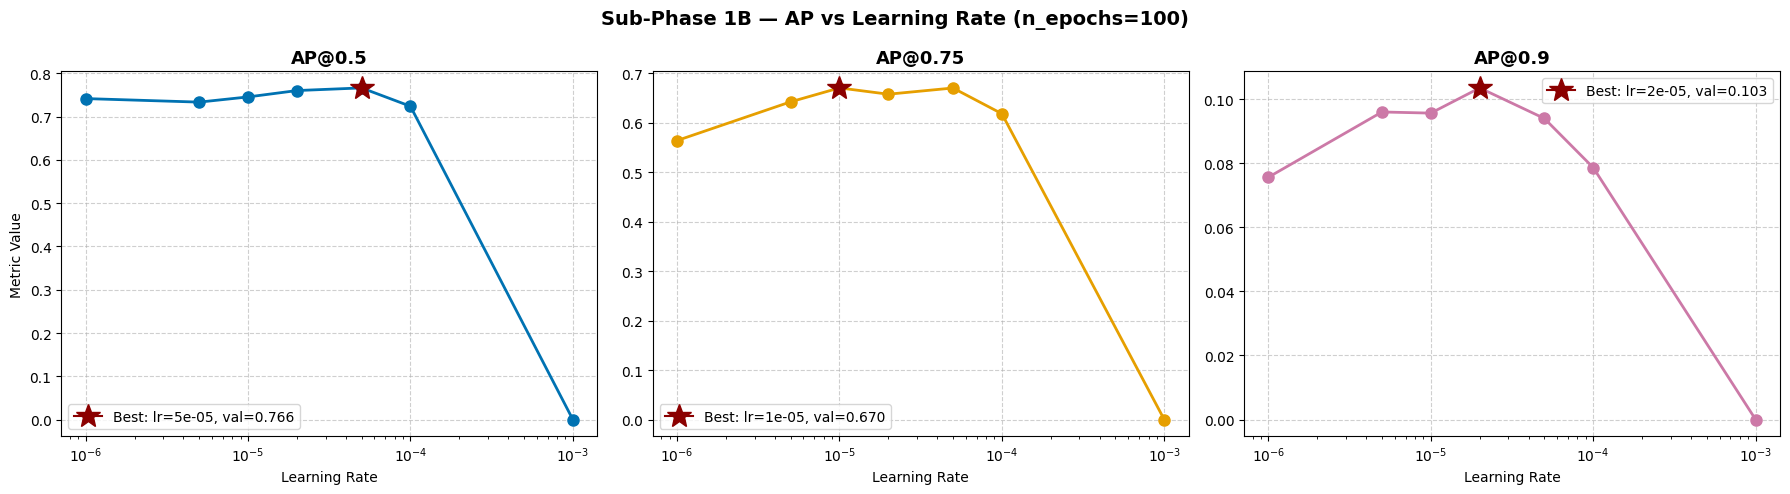

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
ap_metrics = ['AP@0.5_AP', 'AP@0.75_AP', 'AP@0.9_AP']
titles = ['AP@0.5', 'AP@0.75', 'AP@0.9']
colors = ['#0072B2', '#E69F00', '#CC79A7']

for ax, metric, title, color in zip(axes, ap_metrics, titles, colors):
    ax.plot(df_1B_sorted["learning_rate"], df_1B_sorted[metric],
            marker='o', linewidth=2, markersize=8, color=color)

    best_idx = df_1B_sorted[metric].idxmax()
    best_lr = df_1B_sorted.loc[best_idx, "learning_rate"]
    best_val = df_1B_sorted.loc[best_idx, metric]
    ax.plot(best_lr, best_val, marker='*', markersize=18, color='darkred', zorder=5,
            label=f"Best: lr={best_lr}, val={best_val:.3f}")

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel("Learning Rate")
    ax.set_xscale('log')
    if ax == axes[0]:
        ax.set_ylabel("Metric Value")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

fig.suptitle(f"Sub-Phase 1B — AP vs Learning Rate (n_epochs={BEST_EPOCHS})",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(subphase_dir / "1B_ap_comparison_100.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np

# ---------------------------------------------------------------------------
# Learning Rate selection: recommended default, verified as statistically
# equivalent to the empirical best (one-standard-error criterion)
# ---------------------------------------------------------------------------
# The Cellpose documentation recommends lr = 1e-5 for Cellpose-SAM fine-tuning.
# We adopt this recommended value PROVIDED it lies within one standard error of
# the best-performing lr in the sweep (i.e. is statistically indistinguishable
# from the empirical optimum). This anchors the choice on the tool's
# recommendation rather than on noise across only 5 test images.

RECOMMENDED_LR = 1e-5   # Cellpose-SAM default (documentation)

# Empirical peak and its standard error
best_lr_idx = df_1B_sorted["AP@0.5_AP"].idxmax()
peak_lr     = float(df_1B_sorted.loc[best_lr_idx, "learning_rate"])
peak_ap     = float(df_1B_sorted.loc[best_lr_idx, "AP@0.5_AP"])

subphase_dir_1b = SUBPHASE_DIRS["1B_learning_rate"]
model_name_best = df_1B_sorted.loc[best_lr_idx, "model_name"]
per_image_path  = subphase_dir_1b / "per_image_metrics" / f"{model_name_best}_per_image.csv"
df_per_img = pd.read_csv(per_image_path)
n_img = len(df_per_img)
sd_ap = float(df_per_img["AP@0.5_AP"].std(ddof=1))
se_ap = sd_ap / np.sqrt(n_img)
threshold = peak_ap - se_ap

# AP@0.5 of the recommended lr
rec_row = df_1B_sorted[np.isclose(df_1B_sorted["learning_rate"], RECOMMENDED_LR)]
rec_ap  = float(rec_row["AP@0.5_AP"].iloc[0])
is_equivalent = rec_ap >= threshold

BEST_LR = RECOMMENDED_LR   # adopted (pending the equivalence check below)

print("=" * 66)
print("SUB-PHASE 1B — LEARNING RATE SELECTION (recommended default)")
print("=" * 66)
print(f"Fixed: n_epochs = {BEST_EPOCHS}, wd = {DEFAULT_WD}")
print("-" * 66)
print(f"{'learning_rate':>14} | {'AP@0.5':>8} | {'AP@0.75':>8} | {'AP@0.9':>8}")
print("-" * 66)
for _, r in df_1B_sorted.iterrows():
    tags = ""
    if np.isclose(float(r["learning_rate"]), peak_lr):        tags += " [peak]"
    if np.isclose(float(r["learning_rate"]), RECOMMENDED_LR): tags += " [recommended <- ADOPTED]"
    print(f"{r['learning_rate']:>14.0e} | {r['AP@0.5_AP']:>8.4f} | "
          f"{r['AP@0.75_AP']:>8.4f} | {r['AP@0.9_AP']:>8.4f}{tags}")
print("-" * 66)
print(f"Empirical peak: lr = {peak_lr:.0e} (AP@0.5 = {peak_ap:.4f})")
print(f"SE at peak (n={n_img}): {se_ap:.4f}  (SD = {sd_ap:.4f})")
print(f"1-SE threshold: {threshold:.4f}")
print(f"Recommended lr = {RECOMMENDED_LR:.0e}: AP@0.5 = {rec_ap:.4f}")
print(f"Recommended within 1 SE of peak? {is_equivalent}")
print("-" * 66)
if is_equivalent:
    print(f"ADOPTED BEST_LR = {BEST_LR:.0e} "
          f"(recommended default, statistically equivalent to the peak)")
else:
    print(f"WARNING: recommended lr is NOT within 1 SE of the peak "
          f"(rec={rec_ap:.4f} < threshold={threshold:.4f}).")
    print("The 'recommended = equivalent to optimum' argument does NOT hold. Reconsider.")
print("=" * 66)
print(f"\nThis value will center the 1D grid.")

SUB-PHASE 1B — LEARNING RATE SELECTION (recommended default)
Fixed: n_epochs = 100, wd = 0.1
------------------------------------------------------------------
 learning_rate |   AP@0.5 |  AP@0.75 |   AP@0.9
------------------------------------------------------------------
         1e-06 |   0.7418 |   0.5639 |   0.0756
         5e-06 |   0.7336 |   0.6421 |   0.0960
         1e-05 |   0.7456 |   0.6703 |   0.0956 [recommended <- ADOPTED]
         2e-05 |   0.7604 |   0.6575 |   0.1035
         5e-05 |   0.7665 |   0.6701 |   0.0939 [peak]
         1e-04 |   0.7241 |   0.6181 |   0.0786
         1e-03 |   0.0000 |   0.0000 |   0.0000
------------------------------------------------------------------
Empirical peak: lr = 5e-05 (AP@0.5 = 0.7665)
SE at peak (n=5): 0.0225  (SD = 0.0504)
1-SE threshold: 0.7439
Recommended lr = 1e-05: AP@0.5 = 0.7456
Recommended within 1 SE of peak? True
------------------------------------------------------------------
ADOPTED BEST_LR = 1e-05 (recommended 

## Sub-Phase 1C — Weight Decay Exploration

Fixed: `n_epochs = BEST_EPOCHS` (from 1A), `learning_rate = BEST_LR` (from 1B)
Variable: `weight_decay` across 6 values

**Hypothesis:** Strong regularization (high `wd`) is beneficial for the small dataset; very low `wd` causes overfitting at higher epochs.

In [ ]:
subphase_dir = SUBPHASE_DIRS["1C_weight_decay"]
results_1C = []

for wd in WEIGHT_DECAYS_TO_TEST:
    try:
        result = train_and_evaluate(
            n_epochs=BEST_EPOCHS,
            learning_rate=BEST_LR,
            weight_decay=wd,
            subphase_dir=subphase_dir,
            run_label="1C",
            train_data=train_images,
            train_labels=train_masks,
            test_data=test_images,
            test_labels=test_masks,
            test_names_list=test_names,
        )
        results_1C.append(result)

        with open(subphase_dir / "results_partial_100.json", "w") as f:
            json.dump(results_1C, f, indent=4)

        print(f"\n[1C Progress: {len(results_1C)}/{len(WEIGHT_DECAYS_TO_TEST)}]")

    except Exception as e:
        print(f"ERROR at wd={wd}: {e}")
        import traceback
        traceback.print_exc()
        free_gpu_memory()
        continue

with open(subphase_dir / "results_final_100.json", "w") as f:
    json.dump(results_1C, f, indent=4)

df_1C = consolidate_subphase_results(results_1C, subphase_dir, "1C_weight_decay")
df_1C_sorted = df_1C.sort_values("weight_decay").reset_index(drop=True)
df_1C_sorted


TRAINING: 1C_ep100_lr1e-05_wd0.0001_bs1


100%|██████████| 21/21 [00:00<00:00, 157.54it/s]


Model saved: /content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration/1C_weight_decay/models/1C_ep100_lr1e-05_wd0.0001_bs1.pth
Training time: 160.20s (2.67min)
Evaluating on test set...

Results at AP@0.5:
  AP@0.5: 0.7479
  Precision: 0.8359
  Recall: 0.8871
  F1: 0.8607
  TP: 275, FP: 54, FN: 35
AP@0.75: 0.6591
AP@0.9: 0.1178

[1C Progress: 1/6]

TRAINING: 1C_ep100_lr1e-05_wd0.001_bs1


100%|██████████| 21/21 [00:00<00:00, 157.08it/s]


Model saved: /content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration/1C_weight_decay/models/1C_ep100_lr1e-05_wd0.001_bs1.pth
Training time: 159.38s (2.66min)
Evaluating on test set...

Results at AP@0.5:
  AP@0.5: 0.7677
  Precision: 0.8734
  Recall: 0.8677
  F1: 0.8706
  TP: 269, FP: 39, FN: 41
AP@0.75: 0.6663
AP@0.9: 0.1119

[1C Progress: 2/6]

TRAINING: 1C_ep100_lr1e-05_wd0.01_bs1


...

100%|██████████| 21/21 [00:00<00:00, 157.97it/s]


Model saved: /content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration/1C_weight_decay/models/1C_ep100_lr1e-05_wd0.1_bs1.pth
Training time: 160.14s (2.67min)
Evaluating on test set...

Results at AP@0.5:
  AP@0.5: 0.7382
  Precision: 0.8364
  Recall: 0.8742
  F1: 0.8549
  TP: 271, FP: 53, FN: 39
AP@0.75: 0.6607
AP@0.9: 0.1095

[1C Progress: 5/6]

TRAINING: 1C_ep100_lr1e-05_wd0.5_bs1


100%|██████████| 21/21 [00:00<00:00, 157.25it/s]


Model saved: /content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration/1C_weight_decay/models/1C_ep100_lr1e-05_wd0.5_bs1.pth
Training time: 159.94s (2.67min)
Evaluating on test set...

Results at AP@0.5:
  AP@0.5: 0.7565
  Precision: 0.8505
  Recall: 0.8806
  F1: 0.8653
  TP: 273, FP: 48, FN: 37
AP@0.75: 0.6739
AP@0.9: 0.1250

[1C Progress: 6/6]

Summary saved: /content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration/1C_weight_decay/1C_weight_decay_summary.csv


,n_epochs,learning_rate,weight_decay,model_name,training_time_s,train_loss_final,AP@0.5_AP,AP@0.5_TP,AP@0.5_FP,AP@0.5_FN,...,AP@0.75_Precision,AP@0.75_Recall,AP@0.75_F1,AP@0.9_AP,AP@0.9_TP,AP@0.9_FP,AP@0.9_FN,AP@0.9_Precision,AP@0.9_Recall,AP@0.9_F1
0,100,0.00001,0.0001,1C_ep100_lr1e-05_wd0.0001_bs1,160.200234,0.340687,0.747885,275,54,35,...,0.775076,0.822581,0.798122,0.117776,73,256,237,0.221884,0.235484,0.228482
1,100,0.00001,0.0010,1C_ep100_lr1e-05_wd0.001_bs1,159.376685,0.338047,0.767735,269,39,41,...,0.798701,0.793548,0.796116,0.111854,72,236,238,0.233766,0.232258,0.233010
2,100,0.00001,0.0100,1C_ep100_lr1e-05_wd0.01_bs1,157.131248,0.338627,0.763721,277,51,33,...,0.789634,0.835484,0.811912,0.118328,74,254,236,0.225610,0.238710,0.231975
3,100,0.00001,0.0500,1C_ep100_lr1e-05_wd0.05_bs1,158.551027,0.316278,0.745683,270,50,40,...,0.784375,0.809677,0.796825,0.101375,66,254,244,0.206250,0.212903,0.209524
4,100,0.00001,0.1000,1C_ep100_lr1e-05_wd0.1_bs1,160.138253,0.341158,0.738204,271,53,39,...,0.777778,0.812903,0.794953,0.109510,70,254,240,0.216049,0.225806,0.220820
5,100,0.00001,0.5000,1C_ep100_lr1e-05_wd0.5_bs1,159.936029,0.338696,0.756513,273,48,37,...,0.791277,0.819355,0.805071,0.125013,79,242,231,0.246106,0.254839,0.250396


### 1C — Quick Visualization

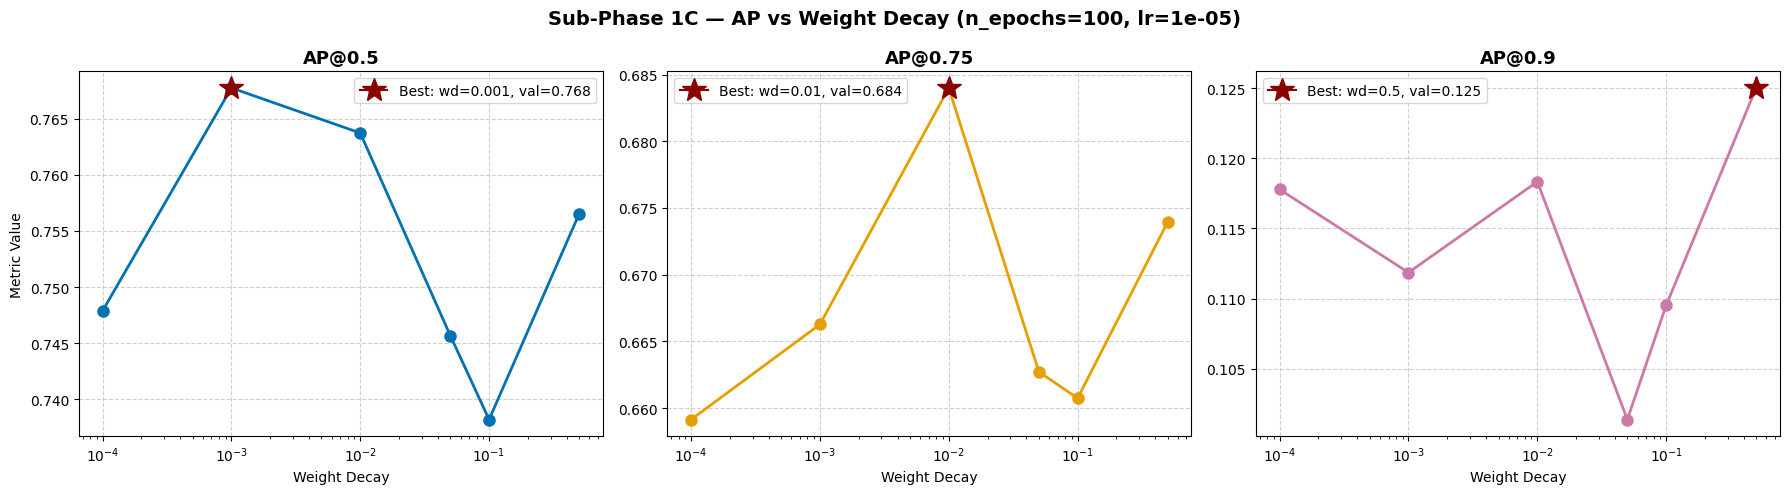

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, metric, title, color in zip(axes, ap_metrics, titles, colors):
    ax.plot(df_1C_sorted["weight_decay"], df_1C_sorted[metric],
            marker='o', linewidth=2, markersize=8, color=color)

    best_idx = df_1C_sorted[metric].idxmax()
    best_wd = df_1C_sorted.loc[best_idx, "weight_decay"]
    best_val = df_1C_sorted.loc[best_idx, metric]
    ax.plot(best_wd, best_val, marker='*', markersize=18, color='darkred', zorder=5,
            label=f"Best: wd={best_wd}, val={best_val:.3f}")

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel("Weight Decay")
    ax.set_xscale('log')
    if ax == axes[0]:
        ax.set_ylabel("Metric Value")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

fig.suptitle(f"Sub-Phase 1C — AP vs Weight Decay (n_epochs={BEST_EPOCHS}, lr={BEST_LR})",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(subphase_dir / "1C_ap_comparison_100.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
best_wd_idx = df_1C_sorted["AP@0.5_AP"].idxmax()
BEST_WD = float(df_1C_sorted.loc[best_wd_idx, "weight_decay"])
print(f"BEST weight_decay (by AP@0.5): {BEST_WD}")
print(f"Best AP@0.5: {df_1C_sorted.loc[best_wd_idx, 'AP@0.5_AP']:.4f}")
print(f"\nThis value will be used as the center for the 1D 2D grid search.")

BEST weight_decay (by AP@0.5): 0.001
Best AP@0.5: 0.7677

This value will be used as the center for the 1D 2D grid search.


In [ ]:
import numpy as np

# ---------------------------------------------------------------------------
# Weight Decay selection: recommended default, verified as statistically
# equivalent to the empirical best (one-standard-error criterion)
# ---------------------------------------------------------------------------
# The Cellpose documentation recommends wd = 0.1 for Cellpose-SAM fine-tuning.
# We adopt this value PROVIDED it lies within one standard error of the best
# wd in the sweep (statistically indistinguishable from the empirical optimum).

RECOMMENDED_WD = 0.1   # Cellpose-SAM default (documentation)

best_wd_idx = df_1C_sorted["AP@0.5_AP"].idxmax()
peak_wd     = float(df_1C_sorted.loc[best_wd_idx, "weight_decay"])
peak_ap     = float(df_1C_sorted.loc[best_wd_idx, "AP@0.5_AP"])

subphase_dir_1c = SUBPHASE_DIRS["1C_weight_decay"]
model_name_best = df_1C_sorted.loc[best_wd_idx, "model_name"]
per_image_path  = subphase_dir_1c / "per_image_metrics" / f"{model_name_best}_per_image.csv"
df_per_img = pd.read_csv(per_image_path)
n_img = len(df_per_img)
sd_ap = float(df_per_img["AP@0.5_AP"].std(ddof=1))
se_ap = sd_ap / np.sqrt(n_img)
threshold = peak_ap - se_ap

rec_row = df_1C_sorted[np.isclose(df_1C_sorted["weight_decay"], RECOMMENDED_WD)]
rec_ap  = float(rec_row["AP@0.5_AP"].iloc[0])
is_equivalent = rec_ap >= threshold

BEST_WD = RECOMMENDED_WD   # adopted (pending the equivalence check)

print("=" * 66)
print("SUB-PHASE 1C — WEIGHT DECAY SELECTION (recommended default)")
print("=" * 66)
print(f"Fixed: n_epochs = {BEST_EPOCHS}, lr = {BEST_LR:.0e}")
print("-" * 66)
print(f"{'weight_decay':>14} | {'AP@0.5':>8} | {'AP@0.75':>8} | {'AP@0.9':>8}")
print("-" * 66)
for _, r in df_1C_sorted.iterrows():
    tags = ""
    if np.isclose(float(r["weight_decay"]), peak_wd):        tags += " [peak]"
    if np.isclose(float(r["weight_decay"]), RECOMMENDED_WD): tags += " [recommended <- ADOPTED]"
    print(f"{r['weight_decay']:>14g} | {r['AP@0.5_AP']:>8.4f} | "
          f"{r['AP@0.75_AP']:>8.4f} | {r['AP@0.9_AP']:>8.4f}{tags}")
print("-" * 66)
print(f"Empirical peak: wd = {peak_wd:g} (AP@0.5 = {peak_ap:.4f})")
print(f"SE at peak (n={n_img}): {se_ap:.4f}  (SD = {sd_ap:.4f})")
print(f"1-SE threshold: {threshold:.4f}")
print(f"Recommended wd = {RECOMMENDED_WD:g}: AP@0.5 = {rec_ap:.4f}")
print(f"Recommended within 1 SE of peak? {is_equivalent}")
print("-" * 66)
if is_equivalent:
    print(f"ADOPTED BEST_WD = {BEST_WD:g} "
          f"(recommended default, statistically equivalent to the peak)")
else:
    print(f"WARNING: recommended wd is NOT within 1 SE of the peak "
          f"(rec={rec_ap:.4f} < threshold={threshold:.4f}).")
    print("The 'recommended = equivalent to optimum' argument does NOT hold. Reconsider.")
print("=" * 66)
print(f"\nThis value will center the 1D grid.")

SUB-PHASE 1C — WEIGHT DECAY SELECTION (recommended default)
Fixed: n_epochs = 100, lr = 1e-05
------------------------------------------------------------------
  weight_decay |   AP@0.5 |  AP@0.75 |   AP@0.9
------------------------------------------------------------------
        0.0001 |   0.7479 |   0.6591 |   0.1178
         0.001 |   0.7677 |   0.6663 |   0.1119 [peak]
          0.01 |   0.7637 |   0.6840 |   0.1183
          0.05 |   0.7457 |   0.6627 |   0.1014
           0.1 |   0.7382 |   0.6607 |   0.1095 [recommended <- ADOPTED]
           0.5 |   0.7565 |   0.6739 |   0.1250
------------------------------------------------------------------
Empirical peak: wd = 0.001 (AP@0.5 = 0.7677)
SE at peak (n=5): 0.0388  (SD = 0.0868)
1-SE threshold: 0.7289
Recommended wd = 0.1: AP@0.5 = 0.7382
Recommended within 1 SE of peak? True
------------------------------------------------------------------
ADOPTED BEST_WD = 0.1 (recommended default, statistically equivalent to the peak)

Thi

## Sub-Phase 1D — Refined 2D Grid Search (lr × wd)

Fixed: `n_epochs = BEST_EPOCHS` (from 1A)
Variable: `learning_rate × weight_decay` (refined grid centered on best values from 1B and 1C)

**Purpose:** Detect interactions between `lr` and `wd` that one-dimensional searches cannot reveal. Test 9 combinations (3 lr × 3 wd) refined around the best region identified in previous sub-phases.

In [ ]:
def get_neighbors_log(value, all_values, n_neighbors=1):
    sorted_vals = sorted(set(all_values))
    if value not in sorted_vals:
        sorted_vals.append(value)
        sorted_vals = sorted(sorted_vals)
    idx = sorted_vals.index(value)

    start = max(0, idx - n_neighbors)
    end = min(len(sorted_vals), idx + n_neighbors + 1)
    return sorted_vals[start:end]


REFINED_LRS = get_neighbors_log(BEST_LR, LEARNING_RATES_TO_TEST, n_neighbors=1)
REFINED_WDS = get_neighbors_log(BEST_WD, WEIGHT_DECAYS_TO_TEST, n_neighbors=1)
combinations = list(product(REFINED_LRS, REFINED_WDS))

print("=" * 68)
print("SUB-PHASE 1D — GRID PREVIEW (lr × wd)")
print("=" * 68)
print(f"Fixed: n_epochs = {BEST_EPOCHS}")
print(f"Grid centered on adopted config: lr = {BEST_LR:.0e}, wd = {BEST_WD:g}")
print("-" * 68)
print(f"Full lr search space : {[f'{v:.0e}' for v in sorted(LEARNING_RATES_TO_TEST)]}")
print(f"  center = {BEST_LR:.0e}  ->  REFINED_LRS = {[f'{v:.0e}' for v in REFINED_LRS]}")
print()
print(f"Full wd search space : {[f'{v:g}' for v in sorted(WEIGHT_DECAYS_TO_TEST)]}")
print(f"  center = {BEST_WD:g}  ->  REFINED_WDS = {[f'{v:g}' for v in REFINED_WDS]}")
print("-" * 68)
print(f"Grid shape: {len(REFINED_LRS)} lr × {len(REFINED_WDS)} wd = "
      f"{len(combinations)} combinations to train")
print("-" * 68)

# tabela visual (linhas = wd, colunas = lr)
col_w = 11
header = "wd \\ lr".ljust(9) + "".join(f"{v:.0e}".rjust(col_w) for v in REFINED_LRS)
print(header)
print("-" * len(header))
for wd in REFINED_WDS:
    row = f"{wd:g}".ljust(9)
    for lr in REFINED_LRS:
        is_center = np.isclose(lr, BEST_LR) and np.isclose(wd, BEST_WD)
        row += ("[CENTER]" if is_center else "train").rjust(col_w)
    print(row)
print("-" * len(header))
print("[CENTER] = recommended config (lr=1e-5, wd=0.1)")

# avisos de borda (não devem disparar, pois os defaults estão no interior)
if len(REFINED_LRS) < 3:
    print(f"\nNote: BEST_LR at edge of search space; only {len(REFINED_LRS)} lr values.")
if len(REFINED_WDS) < 3:
    print(f"\nNote: BEST_WD at edge of search space; only {len(REFINED_WDS)} wd values.")
print("=" * 68)

SUB-PHASE 1D — GRID PREVIEW (lr × wd)
Fixed: n_epochs = 100
Grid centered on adopted config: lr = 1e-05, wd = 0.1
--------------------------------------------------------------------
Full lr search space : ['1e-06', '5e-06', '1e-05', '2e-05', '5e-05', '1e-04', '1e-03']
  center = 1e-05  ->  REFINED_LRS = ['5e-06', '1e-05', '2e-05']

Full wd search space : ['0.0001', '0.001', '0.01', '0.05', '0.1', '0.5']
  center = 0.1  ->  REFINED_WDS = ['0.05', '0.1', '0.5']
--------------------------------------------------------------------
Grid shape: 3 lr × 3 wd = 9 combinations to train
--------------------------------------------------------------------
wd \ lr        5e-06      1e-05      2e-05
------------------------------------------
0.05           train      train      train
0.1            train   [CENTER]      train
0.5            train      train      train
------------------------------------------
[CENTER] = recommended config (lr=1e-5, wd=0.1)


In [ ]:
subphase_dir = SUBPHASE_DIRS["1D_lr_wd_grid"]
results_1D = []

combinations = list(product(REFINED_LRS, REFINED_WDS))

for i, (lr, wd) in enumerate(combinations):
    try:
        result = train_and_evaluate(
            n_epochs=BEST_EPOCHS,
            learning_rate=lr,
            weight_decay=wd,
            subphase_dir=subphase_dir,
            run_label="1D",
            train_data=train_images,
            train_labels=train_masks,
            test_data=test_images,
            test_labels=test_masks,
            test_names_list=test_names,
        )
        results_1D.append(result)

        with open(subphase_dir / "results_partial_100.json", "w") as f:
            json.dump(results_1D, f, indent=4)

        print(f"\n[1D Progress: {len(results_1D)}/{len(combinations)}]")

    except Exception as e:
        print(f"ERROR at lr={lr}, wd={wd}: {e}")
        import traceback
        traceback.print_exc()
        free_gpu_memory()
        continue

with open(subphase_dir / "results_final_100.json", "w") as f:
    json.dump(results_1D, f, indent=4)

df_1D = consolidate_subphase_results(results_1D, subphase_dir, "1D_lr_wd_grid")
df_1D


TRAINING: 1D_ep100_lr5e-06_wd0.05_bs1


100%|██████████| 21/21 [00:00<00:00, 158.10it/s]


Model saved: /content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration/1D_lr_wd_grid/models/1D_ep100_lr5e-06_wd0.05_bs1.pth
Training time: 161.99s (2.70min)
Evaluating on test set...

Results at AP@0.5:
  AP@0.5: 0.7381
  Precision: 0.8433
  Recall: 0.8677
  F1: 0.8553
  TP: 269, FP: 50, FN: 41
AP@0.75: 0.6648
AP@0.9: 0.1059

[1D Progress: 1/9]

TRAINING: 1D_ep100_lr5e-06_wd0.1_bs1


100%|██████████| 21/21 [00:00<00:00, 157.81it/s]


Model saved: /content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration/1D_lr_wd_grid/models/1D_ep100_lr5e-06_wd0.1_bs1.pth
Training time: 158.93s (2.65min)
Evaluating on test set...

Results at AP@0.5:
  AP@0.5: 0.7467
  Precision: 0.8442
  Recall: 0.8742
  F1: 0.8590
  TP: 271, FP: 50, FN: 39
AP@0.75: 0.6437
AP@0.9: 0.1152

[1D Progress: 2/9]

TRAINING: 1D_ep100_lr5e-06_wd0.5_bs1


...

100%|██████████| 21/21 [00:00<00:00, 156.29it/s]


Model saved: /content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration/1D_lr_wd_grid/models/1D_ep100_lr2e-05_wd0.1_bs1.pth
Training time: 158.07s (2.63min)
Evaluating on test set...

Results at AP@0.5:
  AP@0.5: 0.7560
  Precision: 0.8660
  Recall: 0.8548
  F1: 0.8604
  TP: 265, FP: 41, FN: 45
AP@0.75: 0.6513
AP@0.9: 0.0965

[1D Progress: 8/9]

TRAINING: 1D_ep100_lr2e-05_wd0.5_bs1


100%|██████████| 21/21 [00:00<00:00, 157.95it/s]


Model saved: /content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration/1D_lr_wd_grid/models/1D_ep100_lr2e-05_wd0.5_bs1.pth
Training time: 157.62s (2.63min)
Evaluating on test set...

Results at AP@0.5:
  AP@0.5: 0.7533
  Precision: 0.8373
  Recall: 0.8968
  F1: 0.8660
  TP: 278, FP: 54, FN: 32
AP@0.75: 0.6565
AP@0.9: 0.1065

[1D Progress: 9/9]

Summary saved: /content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration/1D_lr_wd_grid/1D_lr_wd_grid_summary.csv


,n_epochs,learning_rate,weight_decay,model_name,training_time_s,train_loss_final,AP@0.5_AP,AP@0.5_TP,AP@0.5_FP,AP@0.5_FN,...,AP@0.75_Precision,AP@0.75_Recall,AP@0.75_F1,AP@0.9_AP,AP@0.9_TP,AP@0.9_FP,AP@0.9_FN,AP@0.9_Precision,AP@0.9_Recall,AP@0.9_F1
0,100,0.000005,0.05,1D_ep100_lr5e-06_wd0.05_bs1,161.987191,0.331254,0.738073,269,50,41,...,0.789969,0.812903,0.801272,0.105900,69,250,241,0.216301,0.222581,0.219396
1,100,0.000005,0.10,1D_ep100_lr5e-06_wd0.1_bs1,158.933640,0.337901,0.746749,271,50,39,...,0.772586,0.800000,0.786054,0.115213,73,248,237,0.227414,0.235484,0.231379
2,100,0.000005,0.50,1D_ep100_lr5e-06_wd0.5_bs1,161.392605,0.345571,0.749634,271,47,39,...,0.789308,0.809677,0.799363,0.101362,64,254,246,0.201258,0.206452,0.203822
3,100,0.000010,0.05,1D_ep100_lr1e-05_wd0.05_bs1,161.824559,0.338727,0.761675,268,40,42,...,0.808442,0.803226,0.805825,0.111826,71,237,239,0.230519,0.229032,0.229773
4,100,0.000010,0.10,1D_ep100_lr1e-05_wd0.1_bs1,160.335106,0.328813,0.773572,279,48,31,...,0.785933,0.829032,0.806907,0.118057,74,253,236,0.226300,0.238710,0.232339
5,100,0.000010,0.50,1D_ep100_lr1e-05_wd0.5_bs1,158.157603,0.341605,0.746025,265,43,45,...,0.795455,0.790323,0.792880,0.116769,68,240,242,0.220779,0.219355,0.220065
6,100,0.000020,0.05,1D_ep100_lr2e-05_wd0.05_bs1,159.711166,0.307466,0.747578,275,51,35,...,0.788344,0.829032,0.808176,0.123598,76,250,234,0.233129,0.245161,0.238994
7,100,0.000020,0.10,1D_ep100_lr2e-05_wd0.1_bs1,158.073780,0.334965,0.755972,265,41,45,...,0.800654,0.790323,0.795455,0.096468,59,247,251,0.192810,0.190323,0.191558
8,100,0.000020,0.50,1D_ep100_lr2e-05_wd0.5_bs1,157.615811,0.321693,0.753251,278,54,32,...,0.771084,0.825806,0.797508,0.106544,67,265,243,0.201807,0.216129,0.208723


### 1D — Visualization (Heatmap)

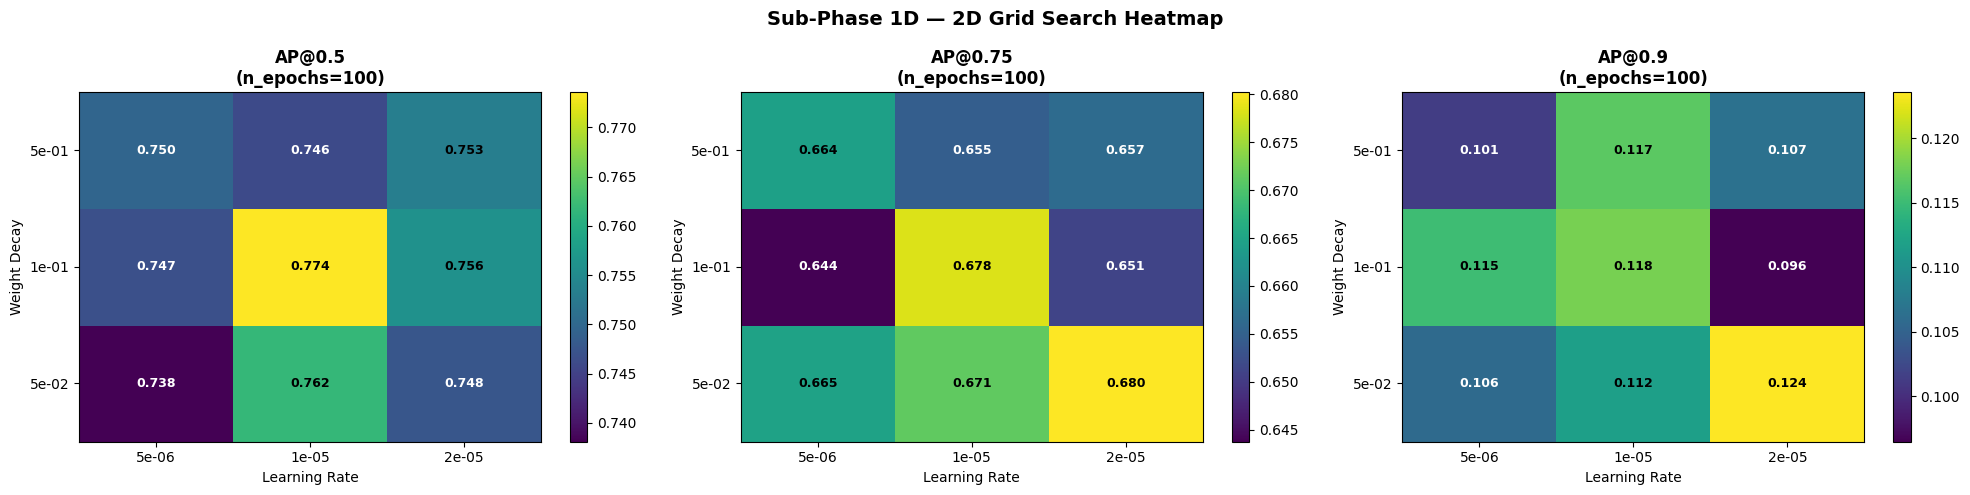

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, metric, title in zip(axes, ap_metrics, titles):
    pivot = df_1D.pivot(index="weight_decay", columns="learning_rate", values=metric)

    im = ax.imshow(pivot.values, cmap='viridis', aspect='auto', origin='lower')

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{x:.0e}" for x in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{y:.0e}" for y in pivot.index])

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            color = 'white' if val < pivot.values.mean() else 'black'
            ax.text(j, i, f"{val:.3f}", ha='center', va='center',
                    color=color, fontsize=9, fontweight='bold')

    ax.set_title(f"{title}\n(n_epochs={BEST_EPOCHS})", fontsize=12, fontweight='bold')
    ax.set_xlabel("Learning Rate")
    ax.set_ylabel("Weight Decay")
    plt.colorbar(im, ax=ax)

fig.suptitle("Sub-Phase 1D — 2D Grid Search Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(subphase_dir / "1D_heatmap_100.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd

# Recover df_1D from Google Drive after session restart
path_1D = SUBPHASE_DIRS["1D_lr_wd_grid"] / "1D_lr_wd_grid_summary.csv"
if not path_1D.exists():
    path_1D = SUBPHASE_DIRS["1D_lr_wd_grid"] / "1D_lr_wd_grid_summary_100.csv"
df_1D = pd.read_csv(path_1D)

best_idx_1D = df_1D["AP@0.5_AP"].idxmax()
FINAL_BEST_EPOCHS = int(df_1D.loc[best_idx_1D, "n_epochs"])
FINAL_BEST_LR = float(df_1D.loc[best_idx_1D, "learning_rate"])
FINAL_BEST_WD = float(df_1D.loc[best_idx_1D, "weight_decay"])

print("=" * 70)
print("FINAL BEST CONFIGURATION (Phase 1)")
print("=" * 70)
print(f"n_epochs:      {FINAL_BEST_EPOCHS}")
print(f"learning_rate: {FINAL_BEST_LR}")
print(f"weight_decay:  {FINAL_BEST_WD}")
print(f"AP@0.5:        {df_1D.loc[best_idx_1D, 'AP@0.5_AP']:.4f}")
print(f"AP@0.75:       {df_1D.loc[best_idx_1D, 'AP@0.75_AP']:.4f}")
print(f"AP@0.9:        {df_1D.loc[best_idx_1D, 'AP@0.9_AP']:.4f}")
print(f"F1@0.5:        {df_1D.loc[best_idx_1D, 'AP@0.5_F1']:.4f}")

FINAL BEST CONFIGURATION (Phase 1)
n_epochs:      100
learning_rate: 1e-05
weight_decay:  0.1
AP@0.5:        0.7736
AP@0.75:       0.6783
AP@0.9:        0.1181
F1@0.5:        0.8760


## 5. Final Phase 1 Consolidation

In [ ]:
import numpy as np, json

total_models_trained = 0
for sp_name, sp_dir in SUBPHASE_DIRS.items():
    csv_file = sp_dir / f"{sp_name}_summary.csv"
    if not csv_file.exists():
        csv_file = sp_dir / f"{sp_name}_summary_100.csv"
    if csv_file.exists():
        total_models_trained += len(pd.read_csv(csv_file))

best_idx_1D     = df_1D["AP@0.5_AP"].idxmax()
FINAL_BEST_LR   = float(df_1D.loc[best_idx_1D, "learning_rate"])
FINAL_BEST_WD   = float(df_1D.loc[best_idx_1D, "weight_decay"])
FINAL_BEST_EPOCHS = int(df_1D.loc[best_idx_1D, "n_epochs"])

expected = (1e-5, 0.1, 100)
got      = (FINAL_BEST_LR, FINAL_BEST_WD, FINAL_BEST_EPOCHS)
if not (np.isclose(FINAL_BEST_LR, 1e-5) and np.isclose(FINAL_BEST_WD, 0.1)
        and FINAL_BEST_EPOCHS == 100):
    print(f"WARNING: final config {got} difere da recomendada {expected}!")
    print("Verifique antes de prosseguir — pode haver incoerência com a Fase 2.")
else:
    print(f"OK: config final = {got} (config recomendada do Cellpose, validada pela grade).")

REFINED_LRS = get_neighbors_log(BEST_LR, LEARNING_RATES_TO_TEST, n_neighbors=1)
REFINED_WDS = get_neighbors_log(BEST_WD, WEIGHT_DECAYS_TO_TEST, n_neighbors=1)

final_config = {
    "phase1_completion": {
        "subphase_1A_best_epochs": BEST_EPOCHS,
        "subphase_1B_best_lr": BEST_LR,
        "subphase_1C_best_wd": BEST_WD,
        "subphase_1D_final_best": {
            "n_epochs": FINAL_BEST_EPOCHS,
            "learning_rate": FINAL_BEST_LR,
            "weight_decay": FINAL_BEST_WD,
        },
    },
    "selection_criteria": {
        "epochs": "one-standard-error rule (parsimony); also the Cellpose recommended value",
        "learning_rate": "Cellpose recommended default (1e-5), verified within 1 SE of the empirical peak",
        "weight_decay": "Cellpose recommended default (0.1), verified within 1 SE of the empirical peak",
        "grid_1D": "immediate neighbours of the adopted values in the search space",
    },
    "best_metrics_at_final_config": {
        "AP@0.5": float(df_1D.loc[best_idx_1D, "AP@0.5_AP"]),
        "AP@0.75": float(df_1D.loc[best_idx_1D, "AP@0.75_AP"]),
        "AP@0.9": float(df_1D.loc[best_idx_1D, "AP@0.9_AP"]),
        "F1@0.5": float(df_1D.loc[best_idx_1D, "AP@0.5_F1"]),
    },
    "search_spaces": {
        "epochs": EPOCHS_TO_TEST,
        "learning_rates": LEARNING_RATES_TO_TEST,
        "weight_decays": WEIGHT_DECAYS_TO_TEST,
        "refined_lr_grid_1D": REFINED_LRS,
        "refined_wd_grid_1D": REFINED_WDS,
    },
    "total_models_trained": total_models_trained,
    "dataset": test_manifest,
}

with open(OUTPUT_DIR / "phase1_final_summary_100.json", "w") as f:
    json.dump(final_config, f, indent=4)

print(json.dumps(final_config, indent=2))

OK: config final = (1e-05, 0.1, 100) (config recomendada do Cellpose, validada pela grade).
{
  "phase1_completion": {
    "subphase_1A_best_epochs": 100,
    "subphase_1B_best_lr": 2e-05,
    "subphase_1C_best_wd": 0.01,
    "subphase_1D_final_best": {
      "n_epochs": 100,
      "learning_rate": 1e-05,
      "weight_decay": 0.1
    }
  },
  "selection_criteria": {
    "epochs": "one-standard-error rule (parsimony); also the Cellpose recommended value",
    "learning_rate": "Cellpose recommended default (1e-5), verified within 1 SE of the empirical peak",
    "weight_decay": "Cellpose recommended default (0.1), verified within 1 SE of the empirical peak",
    "grid_1D": "immediate neighbours of the adopted values in the search space"
  },
  "best_metrics_at_final_config": {
    "AP@0.5": 0.7735722661018372,
    "AP@0.75": 0.6783303022384644,
    "AP@0.9": 0.1180574521422386,
    "F1@0.5": 0.8759811566715052
  },
  "search_spaces": {
    "epochs": [
      1,
      10,
      20,
      

In [ ]:
all_dfs = []

for sp_name, sp_dir in SUBPHASE_DIRS.items():
    # Fallback for filenames to handle both original and _100 versions
    csv_file = sp_dir / f"{sp_name}_summary.csv"
    if not csv_file.exists():
        csv_file = sp_dir / f"{sp_name}_summary_100.csv"

    if csv_file.exists():
        df_tmp = pd.read_csv(csv_file)
        df_tmp["subphase"] = sp_name
        all_dfs.append(df_tmp)

if all_dfs:
    df_all_phase1 = pd.concat(all_dfs, ignore_index=True)
    df_all_phase1.to_csv(OUTPUT_DIR / "phase1_all_results_consolidated_100.csv", index=False)
    print(f"Consolidated phase 1 saved: {OUTPUT_DIR / 'phase1_all_results_consolidated_100.csv'}")
    print(f"Total models: {len(df_all_phase1)}")
    display(df_all_phase1)

Consolidated phase 1 saved: /content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase1_full_exploration/phase1_all_results_consolidated_100.csv
Total models: 40


,n_epochs,learning_rate,weight_decay,model_name,training_time_s,train_loss_final,AP@0.5_AP,AP@0.5_TP,AP@0.5_FP,AP@0.5_FN,...,AP@0.75_Recall,AP@0.75_F1,AP@0.9_AP,AP@0.9_TP,AP@0.9_FP,AP@0.9_FN,AP@0.9_Precision,AP@0.9_Recall,AP@0.9_F1,subphase
0,1,0.000010,0.1000,1A_ep1_lr1e-05_wd0.1_bs1,15.338246,1.131013,0.002218,6,2720,304,...,0.009677,0.001976,0.000000,0,2726,310,0.000000,0.000000,0.000000,1A_epochs
1,10,0.000010,0.1000,1A_ep10_lr1e-05_wd0.1_bs1,30.890326,0.461253,0.696540,289,97,21,...,0.793548,0.706897,0.051757,42,344,268,0.108808,0.135484,0.120690,1A_epochs
2,20,0.000010,0.1000,1A_ep20_lr1e-05_wd0.1_bs1,50.484099,0.428014,0.732980,271,57,39,...,0.767742,0.746081,0.047690,36,292,274,0.109756,0.116129,0.112853,1A_epochs
3,40,0.000010,0.1000,1A_ep40_lr1e-05_wd0.1_bs1,88.521643,0.626494,0.689706,289,96,21,...,0.874194,0.779856,0.108718,77,308,233,0.200000,0.248387,0.221583,1A_epochs
4,60,0.000010,0.1000,1A_ep60_lr1e-05_wd0.1_bs1,128.664167,0.458900,0.731030,249,32,61,...,0.741935,0.778342,0.093148,59,222,251,0.209964,0.190323,0.199662,1A_epochs
5,80,0.000010,0.1000,1A_ep80_lr1e-05_wd0.1_bs1,161.314670,0.408127,0.726876,280,63,30,...,0.819355,0.777948,0.103285,70,273,240,0.204082,0.225806,0.214395,1A_epochs
6,100,0.000010,0.1000,1A_ep100_lr1e-05_wd0.1_bs1,197.616669,0.368056,0.761176,264,35,46,...,0.777419,0.791461,0.104655,66,233,244,0.220736,0.212903,0.216749,1A_epochs
7,120,0.000010,0.1000,1A_ep120_lr1e-05_wd0.1_bs1,238.112570,0.462215,0.744874,279,58,31,...,0.825806,0.791345,0.091932,60,277,250,0.178042,0.193548,0.185471,1A_epochs
8,140,0.000010,0.1000,1A_ep140_lr1e-05_wd0.1_bs1,276.876324,0.431347,0.742785,272,49,38,...,0.812903,0.798732,0.101849,64,257,246,0.199377,0.206452,0.202853,1A_epochs
9,160,0.000010,0.1000,1A_ep160_lr1e-05_wd0.1_bs1,317.046638,0.301932,0.764695,270,40,40,...,0.800000,0.800000,0.103598,65,245,245,0.209677,0.209677,0.209677,1A_epochs
